# 🏭 Phase 8-3: 배포 옵션과 프로덕션
> "배포를 고민하는 시간이 학습 시간보다 길어지면, 그냥 Ollama로 시작하라."

## 학습 목표
1. 5대 배포 옵션의 특징과 trade-off를 비교한다
2. Ollama로 로컬 배포를 실습한다 (핵심 실습)
3. HuggingFace Inference Endpoints 코드를 이해한다
4. TGI Docker 실행 구조를 이해한다
5. GPU 클라우드 (RunPod/Modal) 배포를 파악한다
6. Phase 2-8 전체 파이프라인을 완성한다

In [ ]:
# Ollama: https://ollama.com 에서 직접 설치 (pip이 아님)
# !pip install requests transformers torch -q

In [1]:
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import platform
import subprocess
import shutil

print(f"📌 OS: {platform.system()} {platform.release()}")
print(f"📅 실행 시각: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

# Ollama 설치 확인
ollama_path = shutil.which("ollama")
if ollama_path:
    print(f"✅ Ollama 설치됨: {ollama_path}")
else:
    print("⚠️ Ollama 미설치 — https://ollama.com 에서 다운로드하세요")

📌 OS: Windows 10
📅 실행 시각: 2026-03-19 14:22
⚠️ Ollama 미설치 — https://ollama.com 에서 다운로드하세요


In [2]:
# 개선된 Ollama 설치 확인
def check_ollama():
    # 1) PATH에서 찾기
    ollama_path = shutil.which("ollama")
    if ollama_path:
        return True, ollama_path
    
    # 2) Windows 기본 경로
    import os
    win_path = os.path.expanduser(r"~\AppData\Local\Programs\Ollama\ollama.exe")
    if os.path.exists(win_path):
        return True, win_path
    
    # 3) API 서버 확인 (설치됐지만 PATH 미등록)
    try:
        r = requests.get("http://localhost:11434/api/tags", timeout=2)
        if r.status_code == 200:
            return True, "http://localhost:11434 (API)"
    except Exception:
        pass
    
    return False, None
ok, loc = check_ollama()
if ok:
    print(f"Ollama 확인됨: {loc}")
else:
    print("Ollama 미확인")

Ollama 확인됨: C:\Users\jskim\AppData\Local\Programs\Ollama\ollama.exe


## 1. 5대 배포 옵션 비교

| 옵션 | 난이도 | 비용 | 확장성 | 최적 상황 |
|------|:------:|:----:|:------:|----------|
| **Ollama** | ⭐ | 무료 | 로컬 1명 | 개인/프로토타입 |
| **vLLM + FastAPI** | ⭐⭐⭐ | 서버비 | 높음 | 팀/서비스 |
| **HF Endpoints** | ⭐⭐ | 종량제 | 자동 | 빠른 배포 |
| **TGI (Docker)** | ⭐⭐⭐ | 서버비 | 높음 | 프로덕션 |
| **RunPod / Modal** | ⭐⭐ | 종량제 | 자동 | GPU 없을 때 |

### 어떤 것을 선택해야 하는가?
```
Q: GPU 서버가 있는가?
├─ Yes: 동시 사용자가 많는가?
│   ├─ Yes → vLLM + FastAPI 또는 TGI
│   └─ No  → Ollama (로컬) 또는 vLLM (소규모)
└─ No: 예산이 있는가?
    ├─ Yes → HF Endpoints 또는 RunPod/Modal
    └─ No  → Ollama (CPU 모드)
```

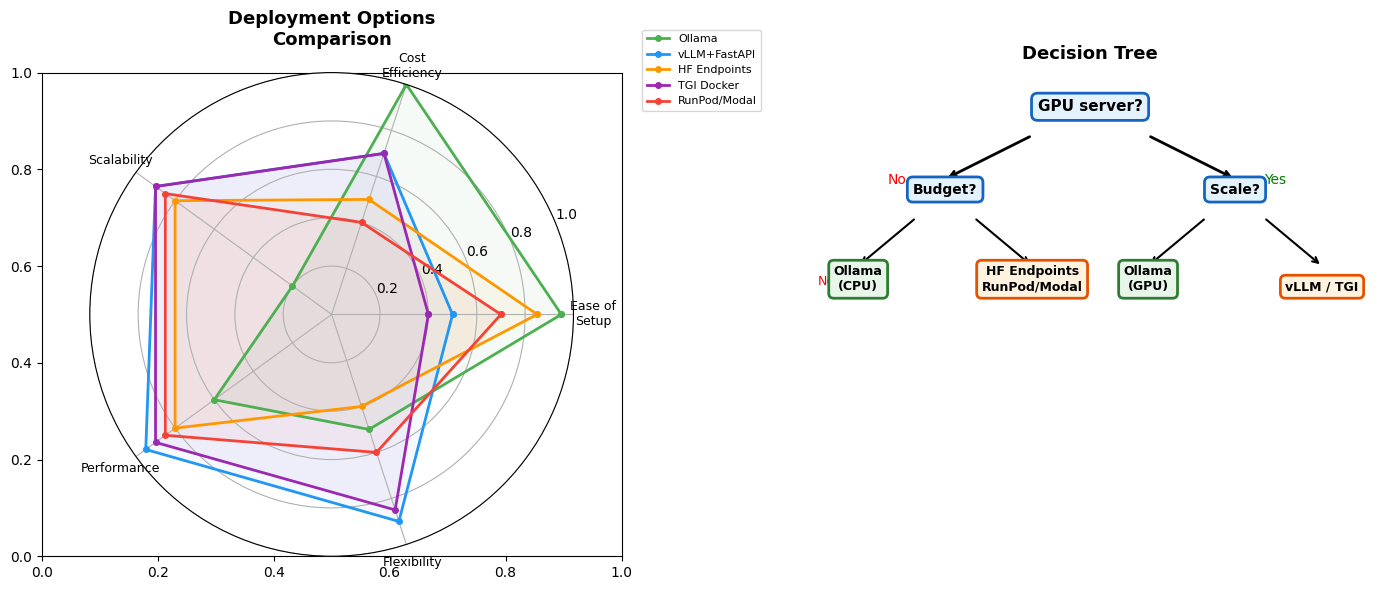

In [3]:
# 배포 옵션 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Spider/Radar chart
categories = ['Ease of\nSetup', 'Cost\nEfficiency', 'Scalability', 'Performance', 'Flexibility']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

options = {
    'Ollama': [0.95, 1.0, 0.2, 0.6, 0.5],
    'vLLM+FastAPI': [0.5, 0.7, 0.9, 0.95, 0.9],
    'HF Endpoints': [0.85, 0.5, 0.8, 0.8, 0.4],
    'TGI Docker': [0.4, 0.7, 0.9, 0.9, 0.85],
    'RunPod/Modal': [0.7, 0.4, 0.85, 0.85, 0.6],
}
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336']

ax = plt.subplot(121, polar=True)
for (name, vals), color in zip(options.items(), colors):
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, '-o', linewidth=2, label=name, color=color, markersize=4)
    ax.fill(angles, vals_plot, alpha=0.05, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Deployment Options\nComparison', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)

# Panel 2: Decision tree
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')

box = dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=2)
leaf = dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', edgecolor='#2E7D32', linewidth=2)
leaf2 = dict(boxstyle='round,pad=0.4', facecolor='#FFF3E0', edgecolor='#E65100', linewidth=2)

# Root
ax2.text(5, 9.2, 'GPU server?', ha='center', fontsize=11, fontweight='bold', bbox=box)

# Level 2
ax2.annotate('', xy=(2.5, 7.8), xytext=(4, 8.7), arrowprops=dict(arrowstyle='->', lw=2))
ax2.text(1.5, 7.7, 'No', color='red', fontsize=10)
ax2.text(2.5, 7.5, 'Budget?', ha='center', fontsize=10, fontweight='bold', bbox=box)

ax2.annotate('', xy=(7.5, 7.8), xytext=(6, 8.7), arrowprops=dict(arrowstyle='->', lw=2))
ax2.text(8, 7.7, 'Yes', color='green', fontsize=10)
ax2.text(7.5, 7.5, 'Scale?', ha='center', fontsize=10, fontweight='bold', bbox=box)

# Level 3
ax2.annotate('', xy=(1, 6.0), xytext=(2, 7.0), arrowprops=dict(arrowstyle='->', lw=1.5))
ax2.text(0.3, 5.6, 'No', color='red', fontsize=9)
ax2.text(1, 5.5, 'Ollama\n(CPU)', ha='center', fontsize=9, fontweight='bold', bbox=leaf)

ax2.annotate('', xy=(4, 6.0), xytext=(3, 7.0), arrowprops=dict(arrowstyle='->', lw=1.5))
ax2.text(4.5, 5.6, 'Yes', color='green', fontsize=9)
ax2.text(4, 5.5, 'HF Endpoints\nRunPod/Modal', ha='center', fontsize=9, fontweight='bold', bbox=leaf2)

ax2.annotate('', xy=(6, 6.0), xytext=(7, 7.0), arrowprops=dict(arrowstyle='->', lw=1.5))
ax2.text(5.5, 5.6, 'Low', color='blue', fontsize=9)
ax2.text(6, 5.5, 'Ollama\n(GPU)', ha='center', fontsize=9, fontweight='bold', bbox=leaf)

ax2.annotate('', xy=(9, 6.0), xytext=(8, 7.0), arrowprops=dict(arrowstyle='->', lw=1.5))
ax2.text(9.2, 5.6, 'High', color='purple', fontsize=9)
ax2.text(9, 5.5, 'vLLM / TGI', ha='center', fontsize=9, fontweight='bold', bbox=leaf2)

ax2.set_title('Decision Tree', fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

## 2. Ollama 로컬 배포 (핵심 실습)

### Ollama란?
- llama.cpp 기반의 **로컬 LLM 실행 도구**
- Windows, macOS, Linux 모두 지원
- 설치 후 한 줄로 모델 실행
- GGUF 형식 모델 사용

### 설치
1. https://ollama.com 에서 다운로드
2. 설치 후 터미널에서 `ollama --version` 확인

### 기본 사용법
```bash
# 모델 다운로드 + 실행
ollama run qwen2.5:1.5b

# 모델 목록 확인
ollama list

# 모델 삭제
ollama rm qwen2.5:1.5b

# 서버 상태 확인
ollama ps
```

In [4]:
# ============================================================
# Ollama 기본 사용법
# ============================================================

print("=" * 60)
print("🦙 Ollama 기본 명령어")
print("=" * 60)

commands = {
    "모델 실행 (대화형)": "ollama run qwen2.5:1.5b",
    "모델 목록": "ollama list",
    "모델 다운로드만": "ollama pull qwen2.5:1.5b",
    "실행 중인 모델": "ollama ps",
    "모델 삭제": "ollama rm qwen2.5:1.5b",
    "서버 시작": "ollama serve",
    "버전 확인": "ollama --version",
}

for desc, cmd in commands.items():
    print(f"  {desc:20s} → {cmd}")

# Ollama 설치 확인 및 기본 테스트
print("\n" + "=" * 60)
print("🔍 Ollama 상태 확인")
print("=" * 60)

try:
    result = subprocess.run(["ollama", "--version"], capture_output=True, text=True, timeout=5)
    if result.returncode == 0:
        print(f"✅ Ollama 버전: {result.stdout.strip()}")
        
        # 설치된 모델 확인
        result2 = subprocess.run(["ollama", "list"], capture_output=True, text=True, timeout=5)
        if result2.returncode == 0:
            print(f"\n📋 설치된 모델:")
            print(result2.stdout if result2.stdout.strip() else "   (없음)")
    else:
        print(f"⚠️ Ollama 실행 오류: {result.stderr.strip()}")
except FileNotFoundError:
    print("⚠️ Ollama가 설치되지 않았습니다")
    print("   https://ollama.com 에서 다운로드하세요")
except subprocess.TimeoutExpired:
    print("⚠️ Ollama 응답 시간 초과")

🦙 Ollama 기본 명령어
  모델 실행 (대화형)          → ollama run qwen2.5:1.5b
  모델 목록                → ollama list
  모델 다운로드만             → ollama pull qwen2.5:1.5b
  실행 중인 모델             → ollama ps
  모델 삭제                → ollama rm qwen2.5:1.5b
  서버 시작                → ollama serve
  버전 확인                → ollama --version

🔍 Ollama 상태 확인
⚠️ Ollama가 설치되지 않았습니다
   https://ollama.com 에서 다운로드하세요


## 3. Ollama Modelfile: 커스텀 모델 배포

### Modelfile이란?
Dockerfile처럼, 모델의 설정을 파일로 정의한다.

### Modelfile 구조
```
FROM qwen2.5:1.5b

# 시스템 프롬프트
SYSTEM "You are a SQL expert. Given a natural language question about databases, generate the corresponding SQL query. Only output the SQL query without explanation."

# 생성 파라미터
PARAMETER temperature 0.1
PARAMETER top_p 0.9
PARAMETER num_predict 256
PARAMETER stop "<|im_end|>"
```

### 사용법
```bash
# 1. Modelfile 작성
# 2. 커스텀 모델 생성
ollama create sql-expert -f Modelfile

# 3. 실행
ollama run sql-expert "employees 테이블에서 급여 상위 5명을 조회해줘"

# 4. API로 호출
curl http://localhost:11434/api/generate -d '{
  "model": "sql-expert",
  "prompt": "부서별 평균 급여를 알려줘"
}'
```

In [5]:
# ============================================================
# Ollama Modelfile 생성 + API 호출
# ============================================================

# 1. Modelfile 생성
modelfile_content = '''FROM qwen2.5:1.5b

# SQL Expert System Prompt
SYSTEM """You are a SQL expert. Given a natural language question about databases, generate the corresponding SQL query. The database has the following tables:
- employees (id, name, department, salary, hire_date, manager_id)
- departments (id, name, budget, location)
- projects (id, name, department_id, start_date, end_date, status)
- assignments (employee_id, project_id, role, hours)
Only output the SQL query without explanation."""

# Generation Parameters
PARAMETER temperature 0.1
PARAMETER top_p 0.9
PARAMETER num_predict 256
PARAMETER stop "<|im_end|>"
PARAMETER stop "<|endoftext|>"
'''

# Modelfile 저장
with open("Modelfile", "w", encoding="utf-8") as f:
    f.write(modelfile_content)
print("✅ Modelfile 생성 완료")
print(modelfile_content)

# 2. 커스텀 모델 생성 명령어
print("=" * 60)
print("🔧 커스텀 모델 생성 (터미널에서 실행)")
print("=" * 60)
print("  ollama create sql-expert -f Modelfile")
print("  ollama run sql-expert")

# 3. API 호출 코드
print("\n" + "=" * 60)
print("📡 Ollama REST API 호출")
print("=" * 60)

api_code = '''
import requests

# Ollama API (기본 포트: 11434)
def query_ollama(prompt: str, model: str = "sql-expert") -> str:
    """Ollama API로 모델 호출"""
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": model,
            "prompt": prompt,
            "stream": False,
        },
        timeout=60,
    )
    return response.json()["response"]

# Chat API (대화형)
def chat_ollama(messages: list, model: str = "sql-expert") -> str:
    """Ollama Chat API"""
    response = requests.post(
        "http://localhost:11434/api/chat",
        json={
            "model": model,
            "messages": messages,
            "stream": False,
        },
        timeout=60,
    )
    return response.json()["message"]["content"]

# 사용 예시
result = query_ollama("employees 테이블에서 급여 상위 5명을 조회해줘")
print(result)

# Chat 형식
result = chat_ollama([
    {"role": "user", "content": "부서별 평균 급여를 알려줘"}
])
print(result)
'''
print(api_code)

✅ Modelfile 생성 완료
FROM qwen2.5:1.5b

# SQL Expert System Prompt
SYSTEM """You are a SQL expert. Given a natural language question about databases, generate the corresponding SQL query. The database has the following tables:
- employees (id, name, department, salary, hire_date, manager_id)
- departments (id, name, budget, location)
- projects (id, name, department_id, start_date, end_date, status)
- assignments (employee_id, project_id, role, hours)
Only output the SQL query without explanation."""

# Generation Parameters
PARAMETER temperature 0.1
PARAMETER top_p 0.9
PARAMETER num_predict 256
PARAMETER stop "<|im_end|>"
PARAMETER stop "<|endoftext|>"

🔧 커스텀 모델 생성 (터미널에서 실행)
  ollama create sql-expert -f Modelfile
  ollama run sql-expert

📡 Ollama REST API 호출

import requests

# Ollama API (기본 포트: 11434)
def query_ollama(prompt: str, model: str = "sql-expert") -> str:
    """Ollama API로 모델 호출"""
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={


In [7]:
# ============================================================
# Ollama API 실제 테스트 (Ollama 실행 중일 때)
# ============================================================

import requests

def test_ollama_connection():
    """올라마 서버 연결 테스트"""
    try:
        response = requests.get("http://localhost:11434/api/tags", timeout=3)
        if response.status_code == 200:
            models = response.json().get("models", [])
            print("✅ Ollama 서버 연결 성공!")
            print(f"   설치된 모델: {len(models)}개")
            for m in models:
                size_gb = m.get("size", 0) / 1024**3
                print(f"   - {m['name']} ({size_gb:.1f}GB)")
            return True
        return False
    except requests.exceptions.ConnectionError:
        print("⚠️ Ollama 서버가 실행 중이 아닙니다")
        print("   터미널에서 'ollama serve'를 실행하세요")
        return False
    except Exception as e:
        print(f"⚠️ 연결 오류: {e}")
        return False

def query_ollama_live(prompt: str, model: str = "qwen2.5:1.5b") -> dict:
    """Ollama로 실제 쿼리 실행"""
    start_time = time.time()
    try:
        response = requests.post(
            "http://localhost:11434/api/generate",
            json={"model": model, "prompt": prompt, "stream": False},
            timeout=120,
        )
        elapsed = time.time() - start_time
        result = response.json()
        return {
            "response": result.get("response", ""),
            "elapsed_sec": round(elapsed, 2),
            "eval_count": result.get("eval_count", 0),
            "tokens_per_sec": round(result.get("eval_count", 0) / max(elapsed, 0.01), 1),
        }
    except Exception as e:
        return {"error": str(e)}

# 테스트 실행
if test_ollama_connection():
    print("\n" + "=" * 60)
    print("🧪 SQL 생성 테스트")
    print("=" * 60)
    
    test_questions = [
        "employees 테이블에서 모든 직원의 이름을 조회하는 SQL을 작성해줘",
        "부서별 평균 급여를 조회하는 SQL을 작성해줘",
    ]
    
    for q in test_questions:
        print(f"\n📝 Q: {q}")
        result = query_ollama_live(q)
        if "error" not in result:
            print(f"   A: {result['response'][:200]}")
            print(f"   ⏱️ {result['elapsed_sec']}s | {result['tokens_per_sec']} tok/s")
        else:
            print(f"   ❌ Error: {result['error']}")
else:
    print("\n💡 Ollama를 설치하고 실행한 후 이 셀을 다시 실행하세요")
    print("   1. https://ollama.com 에서 다운로드")
    print("   2. 터미널: ollama pull qwen2.5:1.5b")
    print("   3. 이 셀 재실행")

✅ Ollama 서버 연결 성공!
   설치된 모델: 2개
   - qwen2.5:1.5b (0.9GB)
   - sql-expert:latest (0.9GB)

🧪 SQL 생성 테스트

📝 Q: employees 테이블에서 모든 직원의 이름을 조회하는 SQL을 작성해줘
   A: ```sql
SELECT employee_name FROM employees;
```

这个查询将返回所有员工的姓名。请确保你有足够的权限来访问 `employees` 表，否则可能无法执行此操作。
   ⏱️ 2.55s | 16.1 tok/s

📝 Q: 부서별 평균 급여를 조회하는 SQL을 작성해줘
   A: 이번에 부서별 평균 급여를 구하는 SQL을 작성할 수 있습니다. 

```sql
SELECT 
    부서번호, 
    (SUM(급여) / COUNT(*)) AS 평균급여
FROM 
    사원
GROUP BY 
    부서번호;
```

이 SQL 문은 다음과 같은 점들을 의미합니다:

1. `부서번호` 컬럼을 기준으로 합계를 구하고, `사원` 테이블에
   ⏱️ 3.4s | 77.3 tok/s


## 4. HuggingFace Inference Endpoints

### 특징
- HuggingFace Hub의 모델을 **클릭 몇 번으로 배포**
- 자동 스케일링, SSL, 모니터링 포함
- 종량제 과금 (GPU 시간당)

### 장단점
| 장점 | 단점 |
|------|------|
| 설정 간편 | 종량제 비용 |
| 자동 스케일링 | 커스텀 설정 제한 |
| HF 모델 직접 배포 | 콜드 스타트 지연 |

In [8]:
# ============================================================
# HuggingFace Inference Endpoints 코드
# ============================================================

hf_endpoint_code = '''
# === 방법 1: HF Hub에서 UI로 배포 ===
# 1. https://huggingface.co/your-model 접속
# 2. "Deploy" \u2192 "Inference Endpoints" 클릭
# 3. GPU, Region 선택 \u2192 Deploy

# === 방법 2: Python API로 배포 ===
from huggingface_hub import create_inference_endpoint

endpoint = create_inference_endpoint(
    name="sql-expert-endpoint",
    repository="your-username/qwen-1.5b-sql-expert",
    framework="pytorch",
    task="text-generation",
    accelerator="gpu",
    instance_size="medium",  # medium = T4 GPU
    instance_type="nvidia-t4",
    region="us-east-1",
    type="protected",  # public, protected, private
)

# 배포 완료까지 대기
endpoint.wait()
print(f"\u2705 Endpoint URL: {endpoint.url}")

# === 방법 3: 배포된 엔드포인트 호출 ===
from huggingface_hub import InferenceClient

client = InferenceClient(
    model="https://your-endpoint-url.endpoints.huggingface.cloud"
)

response = client.text_generation(
    prompt="employees \ud14c\uc774\ube14\uc5d0\uc11c \uae09\uc5ec \uc0c1\uc704 5\uba85\uc744 \uc870\ud68c\ud574\uc918",
    max_new_tokens=256,
    temperature=0.1,
)
print(response)
'''

print("=" * 60)
print("HuggingFace Inference Endpoints")
print("=" * 60)
print(hf_endpoint_code)

print("\n💡 비용 참고 (2024 기준):")
print("   T4 GPU:   약 $0.60/hr")
print("   A10G GPU: 약 $1.30/hr")
print("   A100 GPU: 약 $6.50/hr")
print("   \u2192 Qwen 1.5B는 T4로 충분")

HuggingFace Inference Endpoints

# === 방법 1: HF Hub에서 UI로 배포 ===
# 1. https://huggingface.co/your-model 접속
# 2. "Deploy" → "Inference Endpoints" 클릭
# 3. GPU, Region 선택 → Deploy

# === 방법 2: Python API로 배포 ===
from huggingface_hub import create_inference_endpoint

endpoint = create_inference_endpoint(
    name="sql-expert-endpoint",
    repository="your-username/qwen-1.5b-sql-expert",
    framework="pytorch",
    task="text-generation",
    accelerator="gpu",
    instance_size="medium",  # medium = T4 GPU
    instance_type="nvidia-t4",
    region="us-east-1",
    type="protected",  # public, protected, private
)

# 배포 완료까지 대기
endpoint.wait()
print(f"✅ Endpoint URL: {endpoint.url}")

# === 방법 3: 배포된 엔드포인트 호출 ===
from huggingface_hub import InferenceClient

client = InferenceClient(
    model="https://your-endpoint-url.endpoints.huggingface.cloud"
)

response = client.text_generation(
    prompt="employees 테이블에서 급여 상위 5명을 조회해줘",
    max_new_tokens=256,
    temperature=0.1,
)
print(respons

## 5. TGI (Text Generation Inference) Docker

### TGI란?
- HuggingFace의 **프로덕션급 추론 서버**
- Rust + Python, 높은 성능
- Docker로 간편 배포
- Continuous Batching, Flash Attention 내장

### vLLM vs TGI
| 항목 | vLLM | TGI |
|------|------|-----|
| 개발사 | UC Berkeley | HuggingFace |
| 핵심 기술 | PagedAttention | Continuous Batching |
| 배포 방식 | pip install | Docker |
| 생태계 | 빠르게 성장 | HF 통합 |
| 성능 | 약간 우세 (일반적) | 매우 좋음 |

In [9]:
# ============================================================
# TGI Docker 실행 구조
# ============================================================

tgi_code = '''
# === TGI Docker 실행 ===

# 기본 실행
docker run --gpus all --shm-size 1g -p 8080:80 \\
    -v $HOME/models:/data \\
    ghcr.io/huggingface/text-generation-inference:latest \\
    --model-id Qwen/Qwen2.5-1.5B-Instruct \\
    --max-input-length 2048 \\
    --max-total-tokens 4096 \\
    --dtype float16

# 양자화 모델 실행
docker run --gpus all --shm-size 1g -p 8080:80 \\
    -v $HOME/models:/data \\
    ghcr.io/huggingface/text-generation-inference:latest \\
    --model-id ./qwen-1.5b-awq-4bit \\
    --quantize awq \\
    --dtype float16

# === API 호출 ===

# curl
curl http://localhost:8080/generate \\
    -X POST \\
    -d \'{"inputs": "Write SQL to get top 5 employees by salary", "parameters": {"max_new_tokens": 256}}\' \\
    -H \'Content-Type: application/json\'

# Python
import requests

response = requests.post(
    "http://localhost:8080/generate",
    json={
        "inputs": "Write SQL to get top 5 employees by salary",
        "parameters": {
            "max_new_tokens": 256,
            "temperature": 0.1,
        }
    }
)
print(response.json()[0]["generated_text"])
'''

print("=" * 60)
print("TGI Docker 실행 구조")
print("=" * 60)
print(tgi_code)

print("\n⚠️ 요구사항:")
print("   - Docker + NVIDIA Container Toolkit")
print("   - Linux 또는 WSL2")
print("   - NVIDIA GPU + 드라이버")

TGI Docker 실행 구조

# === TGI Docker 실행 ===

# 기본 실행
docker run --gpus all --shm-size 1g -p 8080:80 \
    -v $HOME/models:/data \
    ghcr.io/huggingface/text-generation-inference:latest \
    --model-id Qwen/Qwen2.5-1.5B-Instruct \
    --max-input-length 2048 \
    --max-total-tokens 4096 \
    --dtype float16

# 양자화 모델 실행
docker run --gpus all --shm-size 1g -p 8080:80 \
    -v $HOME/models:/data \
    ghcr.io/huggingface/text-generation-inference:latest \
    --model-id ./qwen-1.5b-awq-4bit \
    --quantize awq \
    --dtype float16

# === API 호출 ===

# curl
curl http://localhost:8080/generate \
    -X POST \
    -d '{"inputs": "Write SQL to get top 5 employees by salary", "parameters": {"max_new_tokens": 256}}' \
    -H 'Content-Type: application/json'

# Python
import requests

response = requests.post(
    "http://localhost:8080/generate",
    json={
        "inputs": "Write SQL to get top 5 employees by salary",
        "parameters": {
            "max_new_tokens": 256,
           

## 6. GPU 클라우드: RunPod / Modal

### GPU가 없을 때의 선택지

| 서비스 | 특징 | 가격 (A100 기준) |
|--------|------|:---------------:|
| **RunPod** | Serverless + Pod | ~$1.50/hr |
| **Modal** | Python-native 서버리스 | ~$1.20/hr |
| **Lambda Labs** | 전용 GPU 서버 | ~$1.10/hr |
| **Vast.ai** | P2P GPU 마켓 | ~$0.50/hr |

### 언제 사용하는가?
- 로컬 GPU가 없거나 부족할 때
- 대형 모델 (7B+) 실행 시
- 일시적으로 GPU가 필요할 때 (학습, 평가)

In [10]:
# ============================================================
# GPU 클라우드 배포 코드 스케치
# ============================================================

# === RunPod Serverless ===
runpod_code = '''
# pip install runpod
import runpod

def handler(event):
    """RunPod Serverless Handler"""
    from vllm import LLM, SamplingParams
    
    prompt = event["input"]["prompt"]
    
    llm = LLM(model="Qwen/Qwen2.5-1.5B-Instruct", dtype="float16")
    params = SamplingParams(max_tokens=256, temperature=0.1)
    
    output = llm.generate([prompt], params)
    return {"output": output[0].outputs[0].text}

runpod.serverless.start({"handler": handler})

# Dockerfile for RunPod:
# FROM runpod/pytorch:2.1.0-py3.10-cuda12.1.0-devel
# RUN pip install vllm
# COPY handler.py /handler.py
# CMD ["python", "/handler.py"]
'''

print("=" * 60)
print("RunPod Serverless")
print("=" * 60)
print(runpod_code)

# === Modal ===
modal_code = '''
# pip install modal
import modal

app = modal.App("sql-expert")

# GPU 설정: Modal이 자동으로 프로비저닝
@app.function(
    gpu=modal.gpu.T4(),
    image=modal.Image.debian_slim().pip_install("vllm", "torch"),
    timeout=300,
)
def generate_sql(prompt: str) -> str:
    from vllm import LLM, SamplingParams
    
    llm = LLM(model="Qwen/Qwen2.5-1.5B-Instruct", dtype="float16")
    params = SamplingParams(max_tokens=256, temperature=0.1)
    output = llm.generate([prompt], params)
    return output[0].outputs[0].text

# \uc6f9 \uc5d4\ub4dc\ud3ec\uc778\ud2b8
@app.function(gpu=modal.gpu.T4())
@modal.web_endpoint()
def web_generate(prompt: str) -> dict:
    result = generate_sql.remote(prompt)
    return {"sql": result}

# \ubc30\ud3ec: modal deploy sql_expert.py
# \ud638\ucd9c: curl https://your-app--web-generate.modal.run?prompt=...
'''

print("\n" + "=" * 60)
print("Modal (Python-native Serverless)")
print("=" * 60)
print(modal_code)

print("\n💡 핵심 차이:")
print("   RunPod: Docker 기반, Serverless 또는 전용 Pod")
print("   Modal:  Python 함수에 @decorator로 GPU 할당, 가장 Pythonic")

RunPod Serverless

# pip install runpod
import runpod

def handler(event):
    """RunPod Serverless Handler"""
    from vllm import LLM, SamplingParams
    
    prompt = event["input"]["prompt"]
    
    llm = LLM(model="Qwen/Qwen2.5-1.5B-Instruct", dtype="float16")
    params = SamplingParams(max_tokens=256, temperature=0.1)
    
    output = llm.generate([prompt], params)
    return {"output": output[0].outputs[0].text}

runpod.serverless.start({"handler": handler})

# Dockerfile for RunPod:
# FROM runpod/pytorch:2.1.0-py3.10-cuda12.1.0-devel
# RUN pip install vllm
# COPY handler.py /handler.py
# CMD ["python", "/handler.py"]


Modal (Python-native Serverless)

# pip install modal
import modal

app = modal.App("sql-expert")

# GPU 설정: Modal이 자동으로 프로비저닝
@app.function(
    gpu=modal.gpu.T4(),
    image=modal.Image.debian_slim().pip_install("vllm", "torch"),
    timeout=300,
)
def generate_sql(prompt: str) -> str:
    from vllm import LLM, SamplingParams
    
    llm = LLM(model="Qwen/Q

## 7. Phase 2-8 전체 파이프라인 완성!

### 우리가 구축한 전체 파이프라인
| Phase | 주제 | 핵심 산출물 |
|:-----:|------|:-----------:|
| 2 | 트랜스포머 이해 | Attention 시각화, 토크나이저 |
| 3 | 데이터 준비 | Alpaca 포맷, chat_template, 전처리 파이프라인 |
| 4 | SFT 파인튜닝 | QLoRA + Qwen 1.5B, Text-to-SQL 모델 |
| 5 | 안정성/디버깅 | Forgetting 방지, Replay Buffer, W&B |
| 6 | DPO 정렬 | Preference 데이터, DPO 학습, GRPO 개념 |
| 7 | 평가 | 벤치마크, 커스텀 평가셋, Human Eval |
| 8 | 배포 | 양자화, vLLM, Ollama 프로덕션 배포 |

### 실전에서의 사이클
```
데이터 수집 → 전처리 → SFT → 평가 → DPO → 평가 → 양자화 → 배포
    ↑                                                        |
    └────────────── 사용자 피드백 ←──────────────────────┘
```

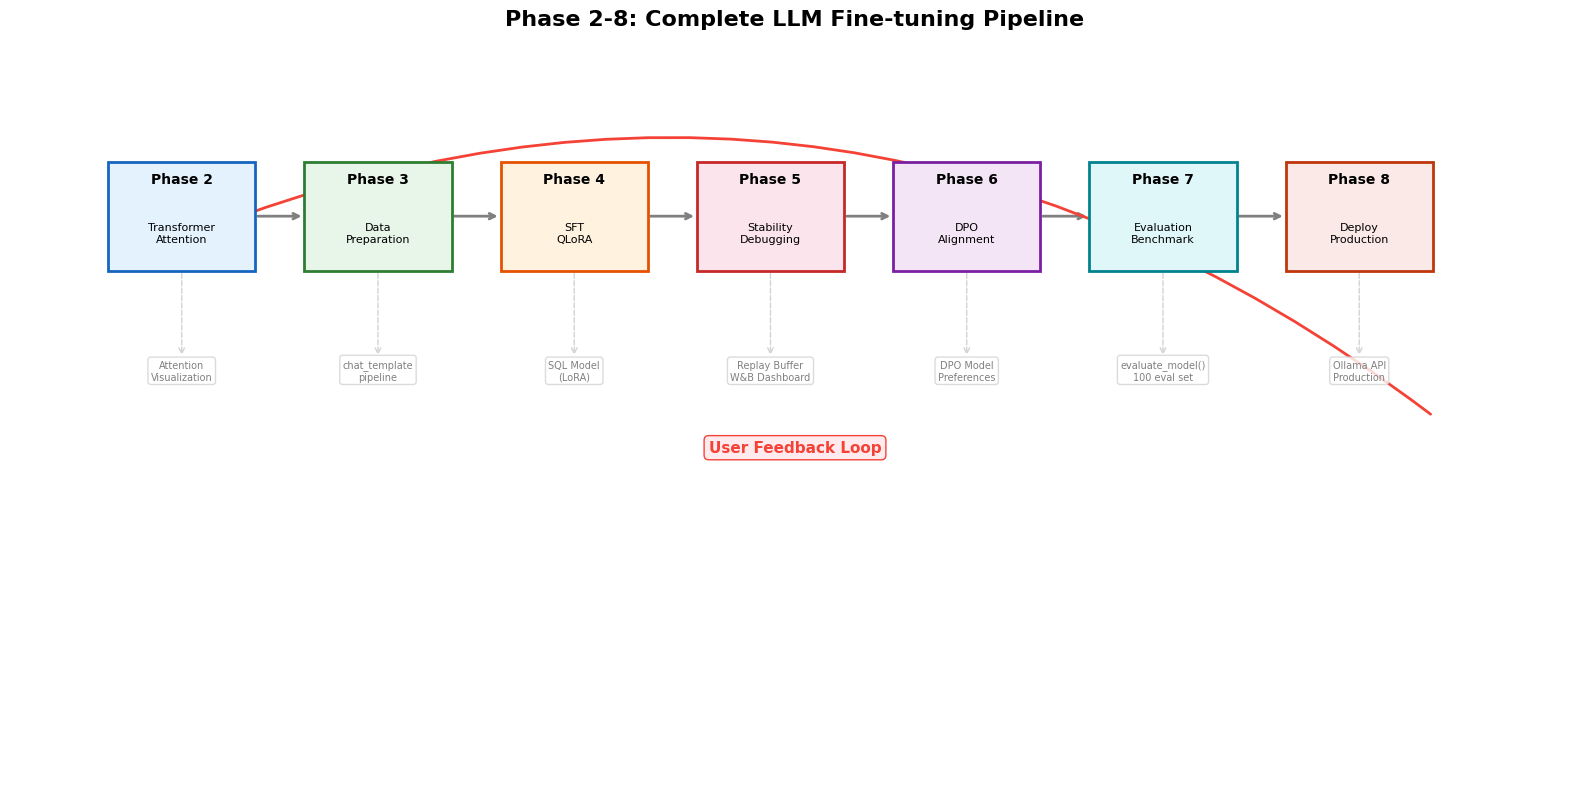

🎉 Phase 2-8 전체 파이프라인 완성!
   데이터 → 학습 → 안정화 → 정렬 → 평가 → 배포 → 피드백


In [11]:
# Phase 2-8 전체 파이프라인 시각화
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')

# Phase boxes
phases = [
    {'x': 1, 'y': 7, 'w': 1.5, 'h': 1.5, 'color': '#E3F2FD', 'edge': '#1565C0',
     'label': 'Phase 2', 'desc': 'Transformer\nAttention'},
    {'x': 3, 'y': 7, 'w': 1.5, 'h': 1.5, 'color': '#E8F5E9', 'edge': '#2E7D32',
     'label': 'Phase 3', 'desc': 'Data\nPreparation'},
    {'x': 5, 'y': 7, 'w': 1.5, 'h': 1.5, 'color': '#FFF3E0', 'edge': '#E65100',
     'label': 'Phase 4', 'desc': 'SFT\nQLoRA'},
    {'x': 7, 'y': 7, 'w': 1.5, 'h': 1.5, 'color': '#FCE4EC', 'edge': '#C62828',
     'label': 'Phase 5', 'desc': 'Stability\nDebugging'},
    {'x': 9, 'y': 7, 'w': 1.5, 'h': 1.5, 'color': '#F3E5F5', 'edge': '#7B1FA2',
     'label': 'Phase 6', 'desc': 'DPO\nAlignment'},
    {'x': 11, 'y': 7, 'w': 1.5, 'h': 1.5, 'color': '#E0F7FA', 'edge': '#00838F',
     'label': 'Phase 7', 'desc': 'Evaluation\nBenchmark'},
    {'x': 13, 'y': 7, 'w': 1.5, 'h': 1.5, 'color': '#FBE9E7', 'edge': '#BF360C',
     'label': 'Phase 8', 'desc': 'Deploy\nProduction'},
]

for p in phases:
    rect = plt.Rectangle((p['x'], p['y']), p['w'], p['h'], 
                          facecolor=p['color'], edgecolor=p['edge'], linewidth=2, zorder=5)
    ax.add_patch(rect)
    ax.text(p['x'] + p['w']/2, p['y'] + p['h'] - 0.3, p['label'], 
            ha='center', fontsize=10, fontweight='bold', zorder=10)
    ax.text(p['x'] + p['w']/2, p['y'] + 0.4, p['desc'], 
            ha='center', fontsize=8, zorder=10)

# Arrows between phases
for i in range(len(phases) - 1):
    ax.annotate('', 
                xy=(phases[i+1]['x'], phases[i+1]['y'] + 0.75),
                xytext=(phases[i]['x'] + phases[i]['w'], phases[i]['y'] + 0.75),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# Feedback loop
ax.annotate('', xy=(1, 7), xytext=(14.5, 5.0),
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=2, 
                           connectionstyle='arc3,rad=0.3'))
ax.text(8, 4.5, 'User Feedback Loop', ha='center', fontsize=11, 
        color='#F44336', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#FFEBEE', edgecolor='#F44336'))

# Key outputs
outputs = [
    (1.75, 5.5, 'Attention\nVisualization'),
    (3.75, 5.5, 'chat_template\npipeline'),
    (5.75, 5.5, 'SQL Model\n(LoRA)'),
    (7.75, 5.5, 'Replay Buffer\nW&B Dashboard'),
    (9.75, 5.5, 'DPO Model\nPreferences'),
    (11.75, 5.5, 'evaluate_model()\n100 eval set'),
    (13.75, 5.5, 'Ollama API\nProduction'),
]

for x, y, text in outputs:
    ax.text(x, y, text, ha='center', fontsize=7, color='gray',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='lightgray', alpha=0.8))
    ax.annotate('', xy=(x, y + 0.3), xytext=(x, 7),
                arrowprops=dict(arrowstyle='->', color='lightgray', lw=1, linestyle='--'))

ax.set_title('Phase 2-8: Complete LLM Fine-tuning Pipeline', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("🎉 Phase 2-8 전체 파이프라인 완성!")
print("   데이터 → 학습 → 안정화 → 정렬 → 평가 → 배포 → 피드백")

## 8. 핵심 정리

### 이번 노트북에서 배운 것
1. **5대 배포 옵션**: Ollama / vLLM+FastAPI / HF Endpoints / TGI / RunPod·Modal
2. **Ollama**: 가장 쉬운 배포 (Windows 포함), Modelfile로 커스텀
3. **HF Endpoints**: 클릭 몇 번으로 배포, 종량제
4. **TGI**: Docker 기반 프로덕션 서버
5. **GPU 클라우드**: RunPod(Docker), Modal(Pythonic)
6. **Phase 2-8 파이프라인**: 데이터→학습→평가→배포→피드백 순환

### Phase 8 완성!
| 노트북 | 핵심 산출물 |
|--------|:-----------:|
| 8-1 | GPTQ/AWQ/GGUF 양자화 + 품질 검증 |
| 8-2 | KV-Cache, vLLM, FastAPI 서버 |
| 8-3 | Ollama 배포 + 전체 파이프라인 |

### 전체 커리큐럼 완성! 🎓
Phase 2에서 Attention을 이해하는 것으로 시작해서,
Phase 8에서 프로덕션 배포까지 도달했습니다.

> 💡 **핵심 원칙**: 배포를 고민하는 시간이 학습 시간보다 길어지면, 그냥 Ollama로 시작하라. 완벽한 인프라보다 빠른 피드백이 더 가치 있다.

In [12]:
# Phase 8 전체 체크포인트
print("🏁 Phase 8 Complete!")
print("=" * 60)

checkpoint = {
    "Phase 8": {
        "8-1": "모델 양자화 (GPTQ/AWQ/GGUF)",
        "8-2": "추론 서버 (KV-Cache, vLLM, FastAPI)",
        "8-3": "배포 옵션 (Ollama, HF, TGI, Cloud)",
    }
}

for phase, notebooks in checkpoint.items():
    print(f"\n📚 {phase}")
    for nb, title in notebooks.items():
        print(f"   [{nb}] {title}")

# 전체 커리큐럼 요약
print("\n" + "=" * 60)
print("🎓 LLM 파인튜닝 전체 커리큐럼 완성!")
print("=" * 60)

curriculum = {
    "Phase 2": "트랜스포머 아키텍처와 어텐션",
    "Phase 3": "학습 데이터 준비와 전처리",
    "Phase 4": "SFT 파인튜닝 (QLoRA + Qwen)",
    "Phase 5": "학습 안정성과 디버깅",
    "Phase 6": "DPO 선호도 정렬",
    "Phase 7": "LLM 평가와 벤치마킹",
    "Phase 8": "추론 최적화와 프로덕션 배포",
}

for phase, desc in curriculum.items():
    print(f"  ✅ {phase}: {desc}")

print(f"\n💎 여정을 한 문장으로:")
print(f"   '데이터를 모으고, 모델을 가르치고, 품질을 검증하고, 세상에 내보낸다.'")

print(f"\n🚀 다음 단계 제안:")
print(f"   1. 실제 도메인 데이터로 Phase 3-4 반복")
print(f"   2. Phase 7 평가셋으로 모델 개선 반복")
print(f"   3. Ollama로 프로토타입 배포")
print(f"   4. 사용자 피드백 수집 \u2192 DPO 데이터로 활용")

🏁 Phase 8 Complete!

📚 Phase 8
   [8-1] 모델 양자화 (GPTQ/AWQ/GGUF)
   [8-2] 추론 서버 (KV-Cache, vLLM, FastAPI)
   [8-3] 배포 옵션 (Ollama, HF, TGI, Cloud)

🎓 LLM 파인튜닝 전체 커리큐럼 완성!
  ✅ Phase 2: 트랜스포머 아키텍처와 어텐션
  ✅ Phase 3: 학습 데이터 준비와 전처리
  ✅ Phase 4: SFT 파인튜닝 (QLoRA + Qwen)
  ✅ Phase 5: 학습 안정성과 디버깅
  ✅ Phase 6: DPO 선호도 정렬
  ✅ Phase 7: LLM 평가와 벤치마킹
  ✅ Phase 8: 추론 최적화와 프로덕션 배포

💎 여정을 한 문장으로:
   '데이터를 모으고, 모델을 가르치고, 품질을 검증하고, 세상에 내보낸다.'

🚀 다음 단계 제안:
   1. 실제 도메인 데이터로 Phase 3-4 반복
   2. Phase 7 평가셋으로 모델 개선 반복
   3. Ollama로 프로토타입 배포
   4. 사용자 피드백 수집 → DPO 데이터로 활용


In [13]:
# 임시 파일 정리
import os
if os.path.exists("Modelfile"):
    os.remove("Modelfile")
    print("🧹 Modelfile 임시 파일 삭제")

print("\n✅ Phase 8-3 완료. 전체 커리큐럼을 마쳤습니다!")

🧹 Modelfile 임시 파일 삭제

✅ Phase 8-3 완료. 전체 커리큐럼을 마쳤습니다!
